Saving phiusiil_cleaned.csv to phiusiil_cleaned (1).csv
Dataset Loaded Successfully
Rows: 195340
Columns: 55


,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,https://www.southbankmosaics.com,31.0,www.southbankmosaics.com,24.0,0.0,com,100.0,1.000000,0.522907,0.061933,...,0.0,0.0,1.0,34.0,20.0,28.0,119.0,0.0,124.0,1.0
1,https://www.uni-mainz.de,23.0,www.uni-mainz.de,16.0,0.0,de,100.0,0.666667,0.032650,0.050207,...,0.0,0.0,1.0,50.0,9.0,8.0,39.0,0.0,217.0,1.0
2,https://www.voicefmradio.co.uk,29.0,www.voicefmradio.co.uk,22.0,0.0,uk,100.0,0.866667,0.028555,0.064129,...,0.0,0.0,1.0,10.0,2.0,7.0,42.0,2.0,5.0,1.0
3,https://www.sfnmjournal.com,26.0,www.sfnmjournal.com,19.0,0.0,com,100.0,1.000000,0.522907,0.057606,...,1.0,1.0,1.0,3.0,27.0,15.0,22.0,1.0,31.0,1.0
4,https://www.rewildingargentina.org,33.0,www.rewildingargentina.org,26.0,0.0,org,100.0,1.000000,0.079963,0.059441,...,1.0,0.0,1.0,244.0,15.0,34.0,72.0,1.0,85.0,1.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195340 entries, 0 to 195339
Data columns (total 55 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   URL                         195340 non-null  object 
 1   URLLength                   195340 non-null  float64
 2   Domain                      195340 non-null  object 
 3   DomainLength                195340 non-null  float64
 4   IsDomainIP                  195340 non-null  float64
 5   TLD                         195340 non-null  object 
 6   URLSimilarityIndex          195340 non-null  float64
 7   CharContinuationRate        195340 non-null  float64
 8   TLDLegitimateProb           195340 non-null  float64
 9   URLCharProb                 195340 non-null  float64
 10  TLDLength                   195340 non-null  float64
 11  NoOfSubDomain               195340 non-null  float64
 12  HasObfuscation              195340 non-null  float64
 13  NoOfObfuscated

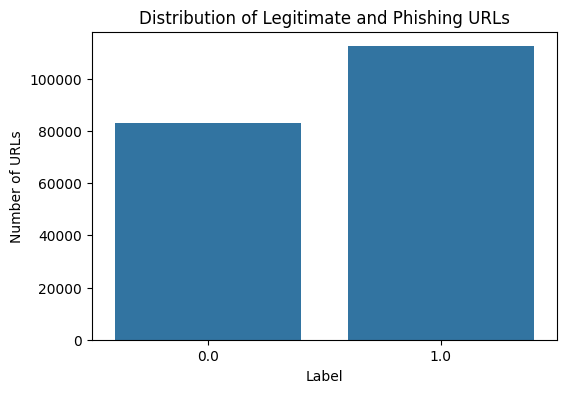

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from google.colab import files
uploaded = files.upload()
df = pd.read_csv('phiusiil_cleaned.csv')

print("Dataset Loaded Successfully")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
df = pd.read_csv('phiusiil_cleaned.csv')
display(df.head())
df.info()
print(df.describe())
print("Label Distribution:")
print(df['label'].value_counts())
print("\nLabel Percentage:")

print(
    df['label']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x='label'
)

plt.title('Distribution of Legitimate and Phishing URLs')
plt.xlabel('Label')
plt.ylabel('Number of URLs')

plt.show()

count    195340.000000
mean         35.068102
std          42.728597
min          14.000000
25%          24.000000
50%          28.000000
75%          34.000000
max        6097.000000
Name: url_length, dtype: float64


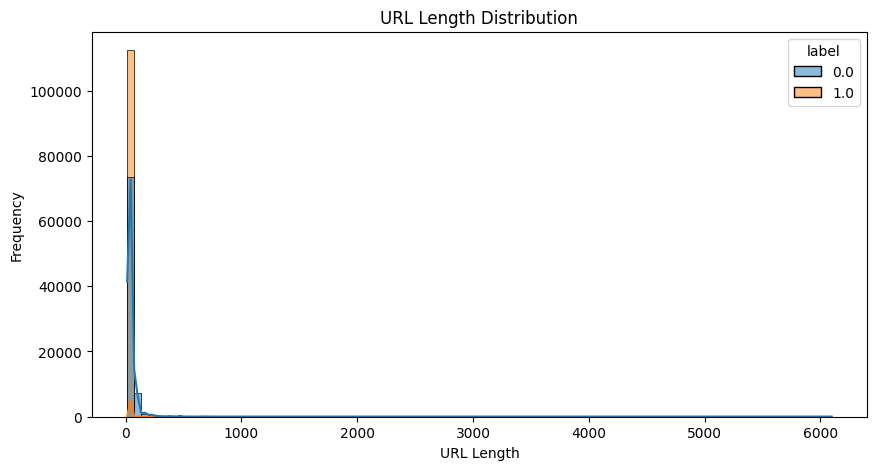

In [2]:
df['url_length'] = df['URL'].str.len()

print(df['url_length'].describe())
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x='url_length',
    hue='label',
    bins=100,
    kde=True
)

plt.title('URL Length Distribution')
plt.xlabel('URL Length')
plt.ylabel('Frequency')

plt.show()

In [3]:
print(
    df.groupby('label')['url_length']
    .mean()
)

label
0.0    45.692877
1.0    27.233824
Name: url_length, dtype: float64


label
0.0    2.387468
1.0    2.161533
Name: num_dots, dtype: float64


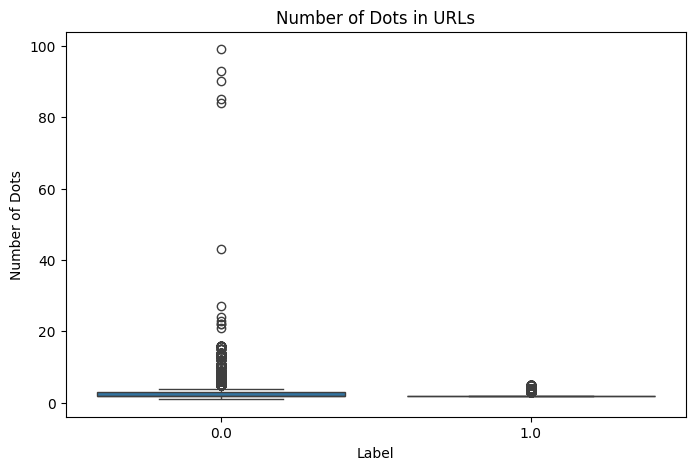

In [4]:
df['num_dots'] = df['URL'].str.count(r'\.')

print(
    df.groupby('label')['num_dots']
    .mean()
)
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='label',
    y='num_dots'
)

plt.title('Number of Dots in URLs')
plt.xlabel('Label')
plt.ylabel('Number of Dots')

plt.show()

label
0.0    4.334238
1.0    0.050429
Name: num_digits, dtype: float64


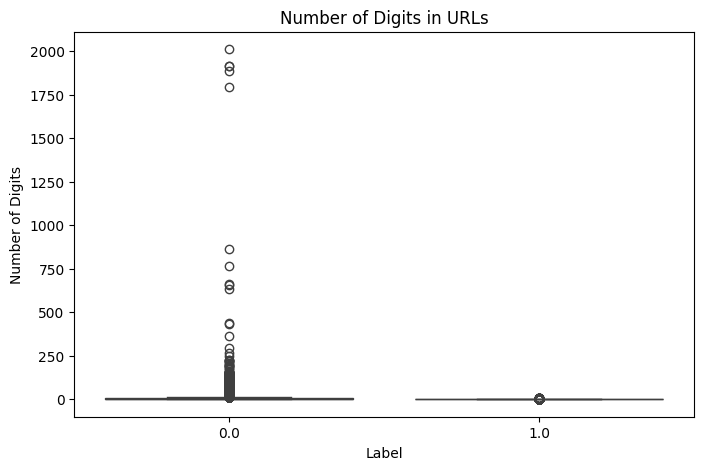

In [5]:
df['num_digits'] = df['URL'].str.count(r'\d')

print(
    df.groupby('label')['num_digits']
    .mean()
)
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='label',
    y='num_digits'
)

plt.title('Number of Digits in URLs')
plt.xlabel('Label')
plt.ylabel('Number of Digits')

plt.show()

label
0.0    1.164791
1.0    0.083622
Name: num_special_chars, dtype: float64


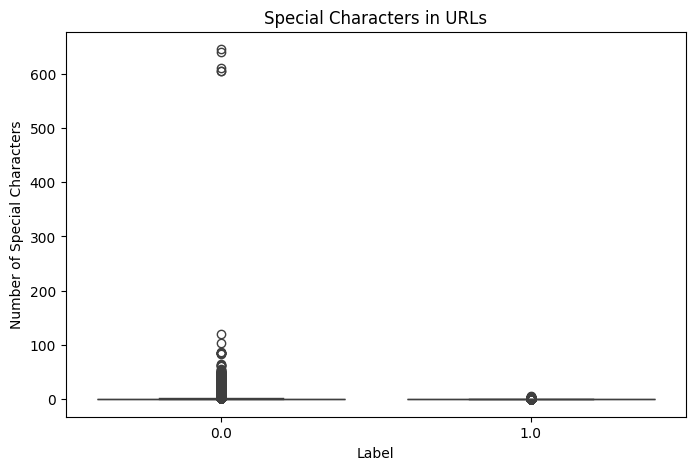

In [6]:
df['num_special_chars'] = df['URL'].str.count(
    r'[@?=&_%\-]'
)

print(
    df.groupby('label')['num_special_chars']
    .mean()
)
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='label',
    y='num_special_chars'
)

plt.title('Special Characters in URLs')
plt.xlabel('Label')
plt.ylabel('Number of Special Characters')

plt.show()

label
0.0    2.642036
1.0    2.000000
Name: num_slashes, dtype: float64


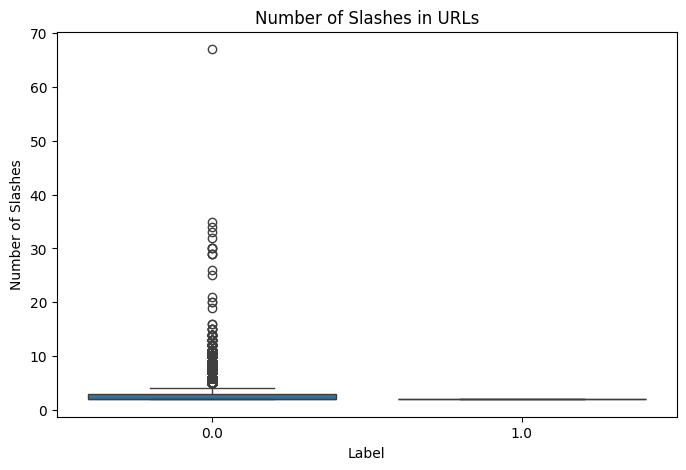

In [7]:
df['num_slashes'] = df['URL'].str.count('/')

print(
    df.groupby('label')['num_slashes']
    .mean()
)
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='label',
    y='num_slashes'
)

plt.title('Number of Slashes in URLs')
plt.xlabel('Label')
plt.ylabel('Number of Slashes')

plt.show()

In [10]:
suspicious_keywords = [
    'login',
    'verify',
    'verification',
    'account',
    'secure',
    'update',
    'password',
    'signin',
    'bank',
    'confirm',
    'paypal'
]

In [11]:
def contains_suspicious_keyword(url):

    url = url.lower()

    for keyword in suspicious_keywords:

        if keyword in url:
            return 1

    return 0
df['suspicious_keyword'] = df['URL'].apply(
    contains_suspicious_keyword
)

print(
    df.groupby('label')['suspicious_keyword']
    .mean()
)

label
0.0    0.070478
1.0    0.003433
Name: suspicious_keyword, dtype: float64


label
0.0    0.006996
1.0    0.000000
Name: has_ip, dtype: float64


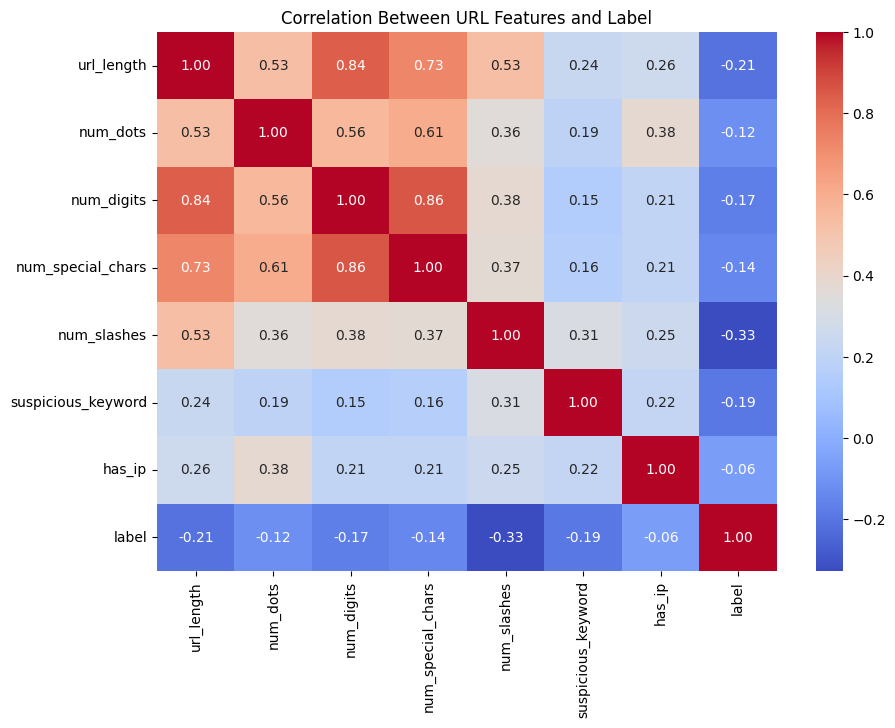

In [12]:
ip_pattern = r'(\d{1,3}\.){3}\d{1,3}'
df['has_ip'] = df['URL'].apply(
    lambda x: int(bool(re.search(ip_pattern, x)))
)

print(
    df.groupby('label')['has_ip']
    .mean()
)
eda_features = [
    'url_length',
    'num_dots',
    'num_digits',
    'num_special_chars',
    'num_slashes',
    'suspicious_keyword',
    'has_ip',
    'label'
]

correlation_matrix = df[eda_features].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Between URL Features and Label')

plt.show()

In [13]:
summary = df.groupby('label')[
    [
        'url_length',
        'num_dots',
        'num_digits',
        'num_special_chars',
        'num_slashes',
        'suspicious_keyword',
        'has_ip'
    ]
].mean()

display(summary)

,url_length,num_dots,num_digits,num_special_chars,num_slashes,suspicious_keyword,has_ip
label,,,,,,,
0.0,45.692877,2.387468,4.334238,1.164791,2.642036,0.070478,0.006996
1.0,27.233824,2.161533,0.050429,0.083622,2.000000,0.003433,0.000000
